In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置样式
sns.set_style("whitegrid")
print("✅ 库导入成功！")

✅ 库导入成功！


In [2]:
df = sns.load_dataset("titanic")

print(f"📊 数据集形状: {df.shape[0]} 行, {df.shape[1]} 列")
print("\n前 5 行:")
display(df.head())

📊 数据集形状: 891 行, 15 列

前 5 行:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("=== 数值型特征统计 ===")
display(df.describe())

print("\n=== 类别型特征统计 ===")
print("性别分布:")
print(df["sex"].value_counts())
print("\n舱位分布:")
print(df["pclass"].value_counts())

=== 数值型特征统计 ===


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



=== 类别型特征统计 ===
性别分布:
sex
male      577
female    314
Name: count, dtype: int64

舱位分布:
pclass
3    491
1    216
2    184
Name: count, dtype: int64


各性别生存率:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


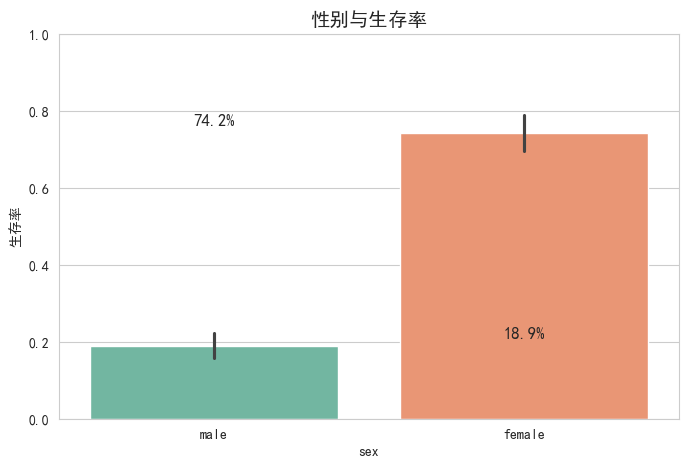

✅ 图表已保存为 1_sex_survival.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ==========放在最开头，解决中文方框警告==========
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams['axes.unicode_minus'] = False
# 屏蔽这两类警告
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message="Glyph*")

# ----------------业务代码----------------
survival_by_sex = df.groupby("sex")["survived"].mean()
print("各性别生存率:")
print(survival_by_sex)

plt.figure(figsize=(8, 5))
# ✅修复FutureWarning：加上hue=x列，legend=False
sns.barplot(data=df, x="sex", y="survived", hue="sex", palette="Set2", legend=False)

plt.title("性别与生存率", fontsize=14)
plt.ylabel("生存率")
plt.ylim(0, 1)

# 在柱子上标注百分比
for i, v in enumerate(survival_by_sex):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=12)

plt.savefig("titanic_project/1_sex_survival.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 图表已保存为 1_sex_survival.png")


各舱位生存率:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


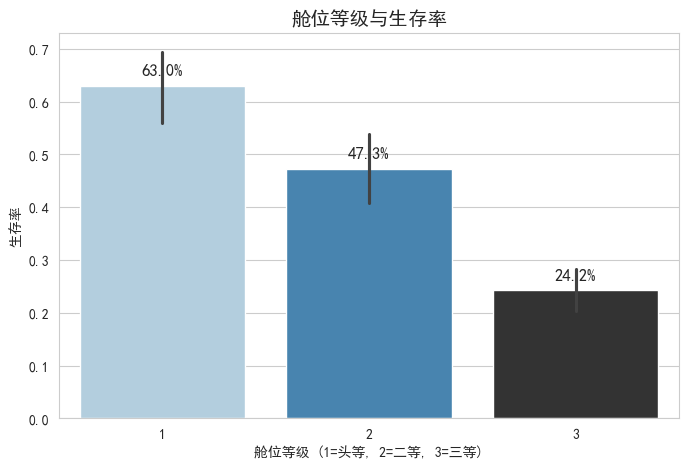

✅ 图表已保存为 2_class_survival.png


In [ ]:
survival_by_class = df.groupby("pclass")["survived"].mean()
print("各舱位生存率:")
print(survival_by_class)
plt.figure(figsize=(8, 5))
# ✅修复警告：增加 hue 和 legend=False
sns.barplot(data=df, x="pclass", y="survived", hue="pclass", palette="Blues_d", legend=False)
plt.title("舱位等级与生存率", fontsize=14)
plt.xlabel("舱位等级 (1=头等, 2=二等, 3=三等)")
plt.ylabel("生存率")
for i, v in enumerate(survival_by_class):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=12)
plt.savefig("titanic_project/2_class_survival.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 图表已保存为 2_class_survival.png")


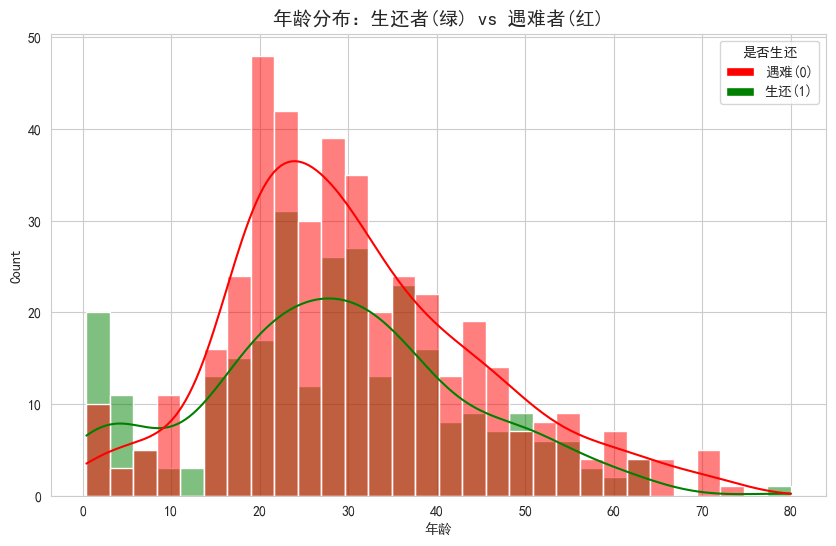

✅ 图表已保存为 3_age_distribution.png


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True, palette=["red", "green"])
plt.title("年龄分布：生还者(绿) vs 遇难者(红)", fontsize=14)
plt.xlabel("年龄")
# 自定义图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='遇难(0)'),
                   Patch(facecolor='green', label='生还(1)')]
plt.legend(handles=legend_elements, title="是否生还")
plt.savefig("titanic_project/3_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 图表已保存为 3_age_distribution.png")


各港口登船者的生存率:
embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64


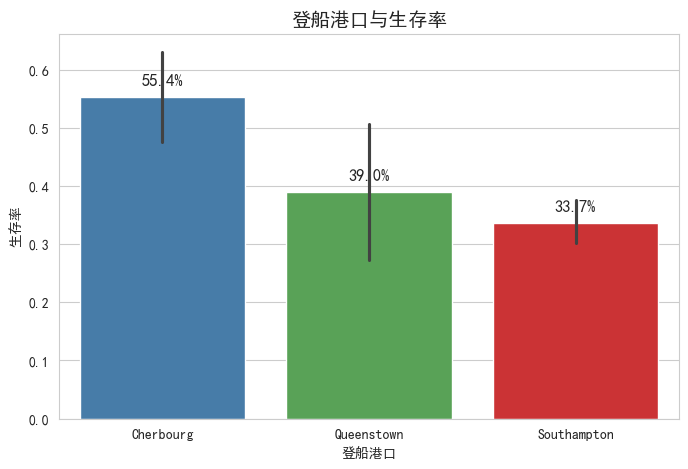

✅ 图表已保存为 4_embark_survival.png


In [ ]:
survival_by_embark = df.groupby("embark_town")["survived"].mean().sort_values(ascending=False)
print("各港口登船者的生存率:")
print(survival_by_embark)
plt.figure(figsize=(8, 5))
# ✅增加 hue 和 legend=False 消除FutureWarning
sns.barplot(data=df, x="embark_town", y="survived", 
            order=survival_by_embark.index, hue="embark_town", palette="Set1", legend=False)
plt.title("登船港口与生存率", fontsize=14)
plt.xlabel("登船港口")
plt.ylabel("生存率")
for i, v in enumerate(survival_by_embark):
    plt.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=12)
plt.savefig("titanic_project/4_embark_survival.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 图表已保存为 4_embark_survival.png")


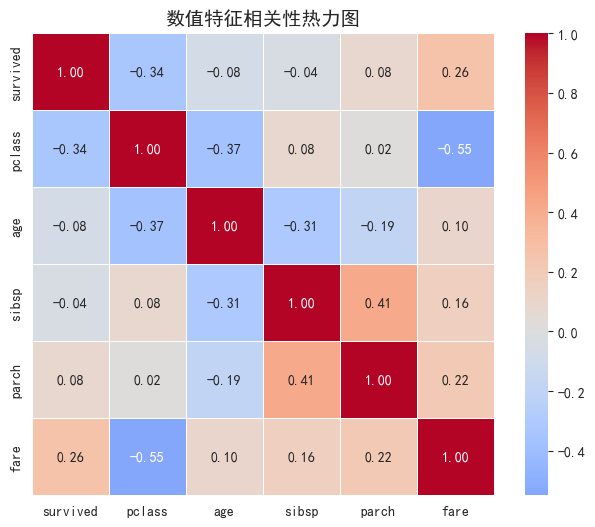

✅ 图表已保存为 5_correlation_heatmap.png


In [ ]:
numeric_df = df[["survived", "pclass", "age", "sibsp", "parch", "fare"]]
corr = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", 
            square=True, linewidths=0.5)
plt.title("数值特征相关性热力图", fontsize=14)
plt.savefig("titanic_project/5_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 图表已保存为 5_correlation_heatmap.png")


## 📝 Week 1 分析结论

通过对 Titanic 数据集（891 名乘客，15 个特征）的探索，我发现：

### 1. 性别是最强预测因素
- 女性生存率：**74.2%**
- 男性生存率：**18.9%**
- "妇女和儿童优先"的逃生原则在数据中得到验证

### 2. 社会经济地位（舱位）显著影响生存
- 头等舱（1st）：**63%**
- 二等舱（2nd）：**47%**
- 三等舱（3rd）：**24%**
- 舱位越差，生存率越低，可能与逃生通道位置、救生艇配额有关

### 3. 年龄呈现"儿童优先"模式
- 从年龄分布图可见，低龄段（0-10岁）绿色（生还）比例明显高于红色（遇难）
- 老年人（60+）生还率极低

### 4. 登船港口与社会阶层相关
- Cherbourg 登船者生存率最高（55%），可能该港口头等舱乘客比例更高
- Southampton 登船者最多，但生存率最低（34%）

### 5. 下一步可以做什么
- 构建预测模型（Week 2），用这些特征预测乘客是否生还
- 做特征工程：构造"家庭人数"、"是否儿童"等新特征
- 处理缺失值：Age 列有约 20% 缺失
